# Goal

The goal of this notebook is to use flexAE to find unresolved binary systems in 47 Tuc using photmetric data from Rubin LSST, similarly to what was done in Géron et al. (2026). Contrary to the other tutorials, this is a two-step process: 1) train/test flexAE on simulated templates and 2) apply it on real data. This is because the real data set does not have reliable labels yet. 


Note that I assume that you are already familiar with autoencoders, MLP classifiers, and training models in PyTorch. If not, there are a ton of other amazing resources out there to help you get familiar with that. I'm also assuming you're familiar with the idea of flexAE, as presented in Géron et al. (2026). I'm also assuming that you already went through tutorials #1 and #2.

# Imports

In [1]:
# General imports
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import warnings

# Sklearn imports
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.datasets import load_iris, load_breast_cancer

# Pytorch imports
import torch
from torch import optim
from torch.utils.data import TensorDataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load flexAE
import sys
sys.path.append("..") #Point this to where the flexAE.py file is located
from flexAE import *

# Code

### Part 1: Loading the data

I have pre-generated a simulated training set of single stars and binary systems at the distance of [47 Tucanae](https://en.wikipedia.org/wiki/47_Tucanae) using the stellar atmosphere models of [Castelli and Kurucz](https://www.stsci.edu/hst/instrumentation/reference-data-for-calibration-and-tools/astronomical-catalogs/castelli-and-kurucz-atlas). For more information on how it was generated, please refer to Géron et al. (2026). Let's open this dataset. You'll notice it has a bunch of columns. It has apparent magnitudes in the $g$, $r$, $i$ bands and their errors, as well as absolute magnitudes, and a few colors. In Géron et al. (2026), we used the $g-r$ and $r-i$ colors and the $r$ band, as well as their uncertainties, as input features for flexAE. However, feel free to experiment with using different features by changing the code below.

In [2]:
df_data = pd.read_csv('data/binary_simulated_sample.csv')

In [3]:
df_data

,g,g_err,r,r_err,i,i_err,g-r,g-r_err,g-i,g-i_err,r-i,r-i_err,g_abs,g_abs_err,r_abs,r_abs_err,i_abs,i_abs_err,Y
0,19.736203,0.004862,19.082368,0.004022,18.834045,0.002604,0.653835,0.006310,0.902158,0.005516,0.248323,0.004791,6.394274,0.004862,5.740438,0.004022,5.492116,0.002604,1
1,21.884686,0.011475,20.814789,0.010341,20.375204,0.004267,1.069897,0.015447,1.509482,0.012243,0.439585,0.011187,8.542756,0.011475,7.472859,0.010341,7.033274,0.004267,1
2,19.696144,0.001889,19.148546,0.004868,18.914649,0.003598,0.547598,0.005222,0.781495,0.004064,0.233897,0.006054,6.354215,0.001889,5.806616,0.004868,5.572720,0.003598,0
3,18.796132,0.002384,18.385932,0.001490,18.231596,0.001918,0.410200,0.002811,0.564536,0.003060,0.154337,0.002429,5.454203,0.002384,5.044003,0.001490,4.889666,0.001918,1
4,21.578232,0.023209,20.731508,0.003687,20.314902,0.012411,0.846724,0.023500,1.263331,0.026319,0.416606,0.012947,8.236303,0.023209,7.389578,0.003687,6.972972,0.012411,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,21.945301,0.035248,20.820938,0.007568,20.311347,0.014230,1.124364,0.036052,1.633955,0.038012,0.509591,0.016117,8.603372,0.035248,7.479008,0.007568,6.969417,0.014230,1
29996,18.713820,0.002168,18.275247,0.002506,18.104537,0.002208,0.438573,0.003313,0.609283,0.003094,0.170710,0.003339,5.371891,0.002168,4.933317,0.002506,4.762607,0.002208,1
29997,19.587032,0.006796,19.192465,0.003801,19.036210,0.005959,0.394567,0.007787,0.550822,0.009038,0.156255,0.007068,6.245102,0.006796,5.850536,0.003801,5.694280,0.005959,0
29998,22.709084,0.046280,21.463386,0.006910,20.812160,0.018182,1.245698,0.046793,1.896924,0.049723,0.651226,0.019451,9.367154,0.046280,8.121457,0.006910,7.470230,0.018182,1


In [4]:
cols_data = ['r','g-r','r-i']
cols_error = ['r_err','g-r_err','r-i_err']
cols_classification = 'Y'

Let's standardize the features and load them into tensors. Note that this is also slightly different from the previous tutorials. First of all, we don't fully standardize the feature uncertainties. Instead, they are divided by the standard deviation of their corresponding data feature to keep the relative ratio of the data features to the corresponding uncertainty features intact. Secondly, the tensor datasets now contain three tensors: the data, the uncertainties, and the classifications.

In [5]:
### Inputs

# The data
X = df_data[cols_data].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) #Transform
X_tensor = torch.tensor(X_scaled, dtype=torch.float32) # Convert to PyTorch Tensors

# Their uncertainties
X_err = df_data[cols_error].values
X_err_scaled = X_err / scaler.scale_
X_err_tensor = torch.tensor(X_err_scaled, dtype=torch.float32)

# The classifications
Y = df_data[cols_classification].values
Y_tensor = torch.tensor(Y, dtype=torch.long)

# The feature names
feature_names = df_data[cols_data].columns

# Create the Dataset
tensor_dataset = TensorDataset(X_tensor,  X_err_tensor, Y_tensor)

# Divide into train and test
test_split = 0.2
train_dataset, test_dataset = split_tensordataset(tensor_dataset, train_fraction=0.8)

### Part 2: Training flexAE

Here, we first configure the training parameters, the optimizer and scheduler, and then initialize the flexAE model with a specific architecture. As you'll notice, we've enabled an extra scatter output component (`include_scatter = True`), a separate input head for the feature uncertainties (`include_error_head = True`), and explicitly also enabled the classifier component (`include_classifier = True`). Please refer to Géron et al. (2026) for more details on these components. Note that we're not using the variational component that was used in Tutorial #2. 

In [6]:
# Config learning parameters
batch_size = 640
epochs = 2_000
learning_rate = 1e-3
gamma = 2.0
validation_split = 0.1

In [7]:
# Initialize model with architecture
model = flexAE(
    input_dim = X_scaled.shape[1],
    head_dim = [12], #this is per head, so the full head dimension will be twice this
    hidden_dim = [16,8],
    latent_dim = 4,
    classifier_dim = [16,16,16],
    include_scatter = True,
    include_classifier = True,
    include_error_head = True
).to(device)

In [8]:
# Initialize optimizer and scheduler
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=epochs//10, factor=0.5)

In [9]:
# Train model
model.train_model(train_dataset, epochs = epochs, learning_rate = learning_rate, batch_size = batch_size, gamma = gamma,
                  validation_split = validation_split, optimizer = optimizer, scheduler = scheduler)

  0%|          | 0/2000 [00:00<?, ?it/s]

### Part 3: Inspect model performance

We will now inspect how the model performs. There are a lot of methods you can use associated with flexAE to help with this process.

Let's inspect the loss curve. There are two distinct losses in flexAE: the reconstruction and BCE classification loss. In the cell below, you'll notice that both of them are going down for the training and validation set, as expected.

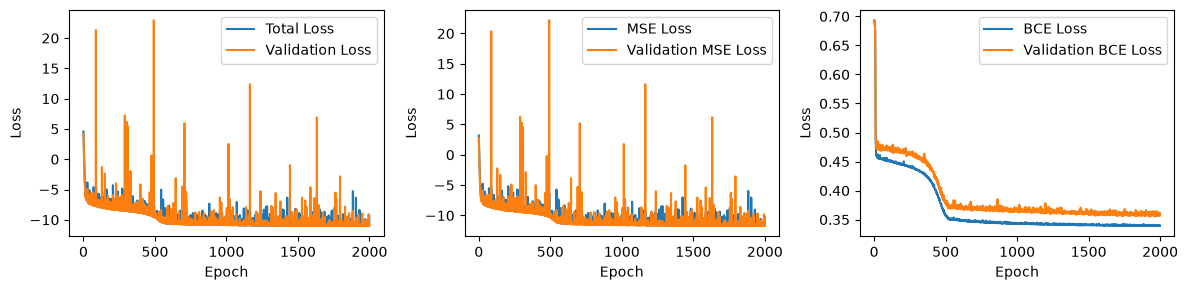

In [10]:
plt.figure(figsize = (12,3))

plt.subplot(1,3,1)
model.plot_loss_per_epoch(losses = ['total','validation'], yscale = 'linear', ax = plt.gca())

plt.subplot(1,3,2)
model.plot_loss_per_epoch(losses = ['mse','val_mse'], yscale = 'linear', ax = plt.gca())

plt.subplot(1,3,3)
model.plot_loss_per_epoch(losses = ['bce','val_bce'], yscale = 'linear', ax = plt.gca())

plt.tight_layout()
plt.show()

Even though the end goal is classification, flexAE also attempts to use its latent space to reconstruct the input features. You can look at the average residuals for each of the input features to get a sense of how good the reconstruction is.

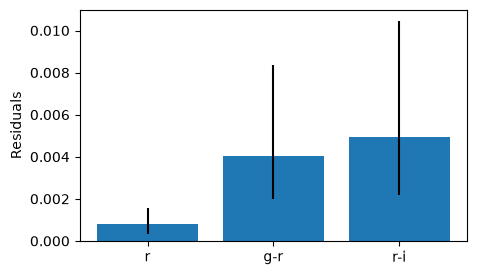

In [11]:
plt.figure(figsize = (5,3))
model.plot_feature_residuals(labels = feature_names, ax = plt.gca())
plt.show()

Instead of looking at the average residuals, you can also directly compare the shape of the input and reconstructed features. It seems like flexAE did a pretty good job. Note that the output also differs slightly from Tutorials #1 and #2, as you can see shaded regions. The blue shaded regions represent the uncertainties around the input features, while the orange shaded regions are the output scatter (which can be very small -- if they are larger than the blue uncertainties then you likely have to train for more epochs).

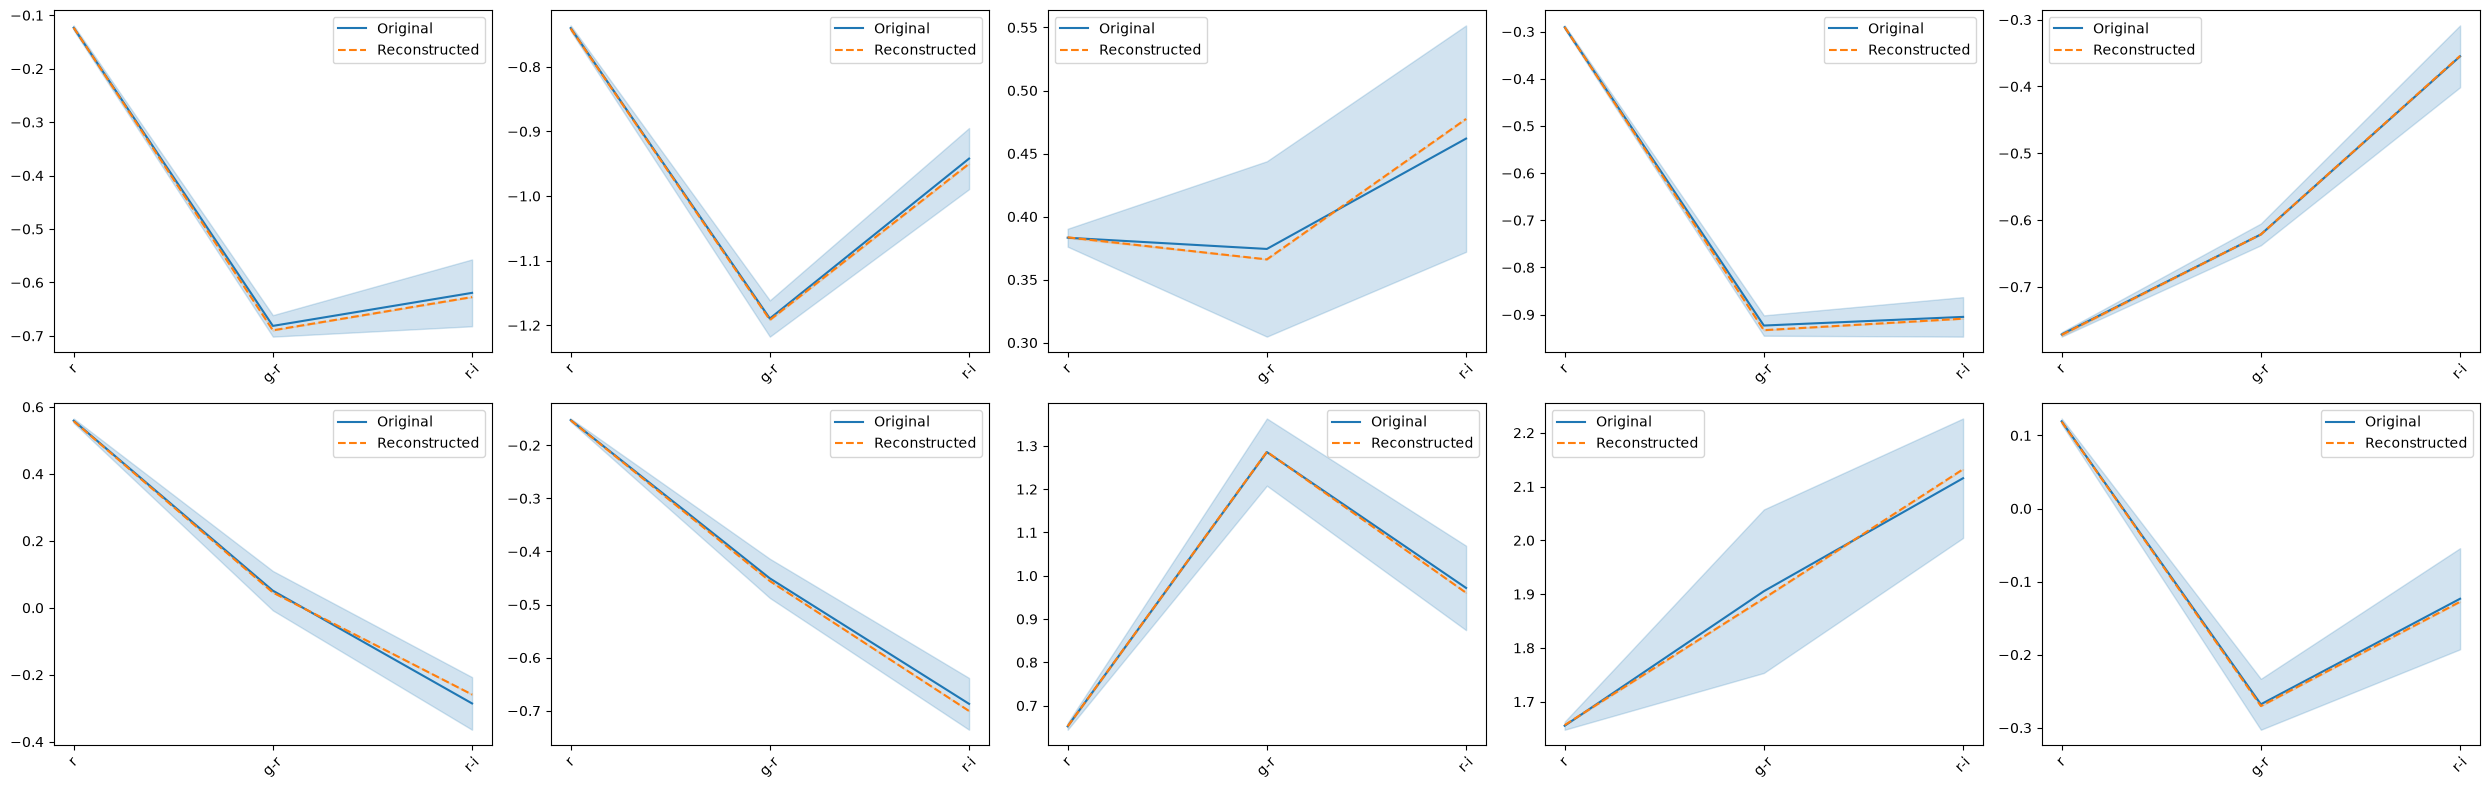

In [12]:
model.compare_reconstructed_features(test_dataset, labels = feature_names)

While reconstruction is important, in this case, we actually mostly care about the classification accuracy. Let's inspect the latent space to see where the two classes are located. We can do this by running the `encode` method, as shown below. Note that, in contrast with Tutorials #1 and #2, the `encode` method now needs both the input features, and the feature uncertainties. This method returns a dictionary with the encoder output, which in out case only includes the latent space locations (saved in `mu`). We're then using seaborn to plot. It seems like the two classes separate out well, which is promising!

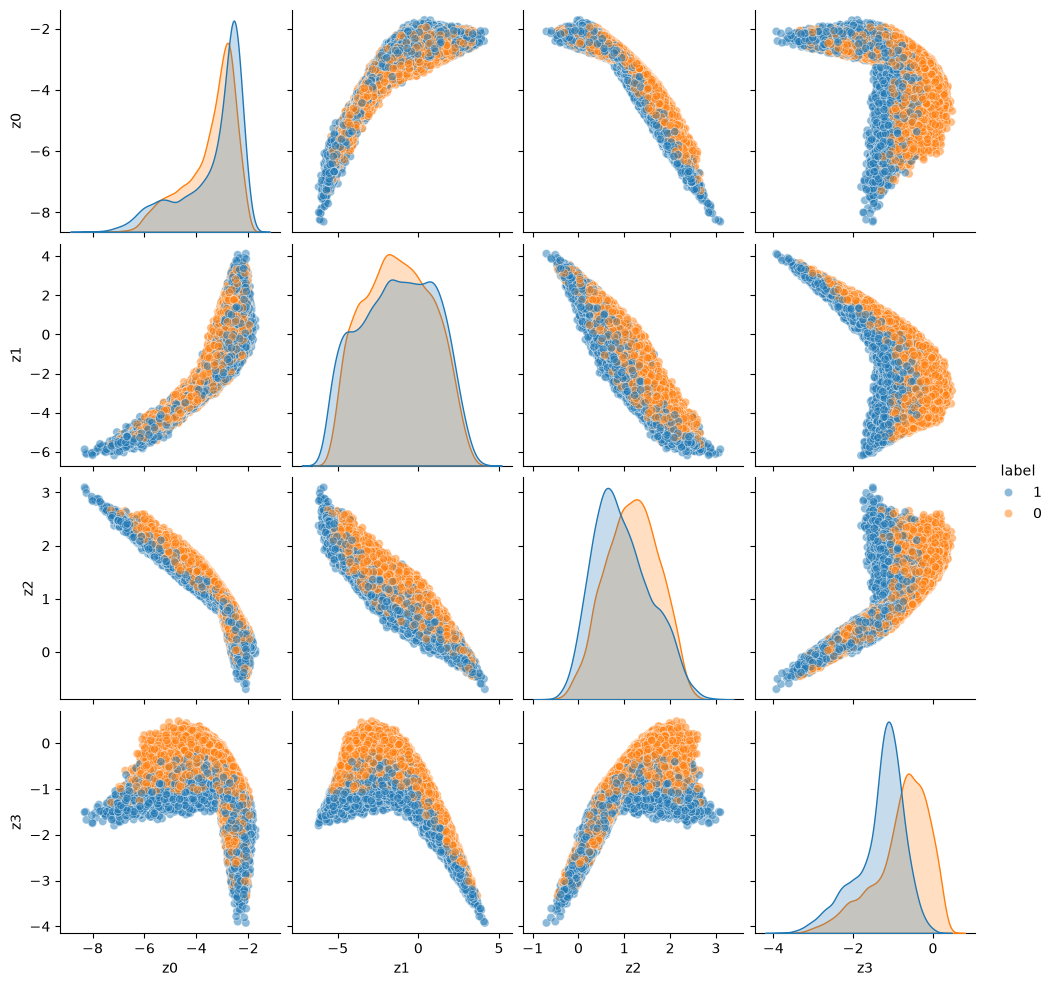

In [13]:
model.eval()
with torch.no_grad():
    data, data_err, Y_true = train_dataset.tensors
    Y_true = Y_true.numpy()
    
    encoder_output = model.encode(data, data_err)
    mu = encoder_output['mu'].detach().cpu().numpy()


warnings.filterwarnings("ignore", module="seaborn")

df_latent = pd.DataFrame(mu, columns=[f'z{i}' for i in range(mu.shape[1])])
df_latent['label'] = Y_true.astype(str)

sns.pairplot(df_latent, hue='label', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.show()

We will now explicitly look at the classification performance. You can get classification predictions by running `model()`. Similarly to above, this now needs both the input features and the feature uncertainties. This returns a dictionary that contains the reconstructed features, the latent space locations (mu), and the classification predictions. We care about the latter. We get a pretty good classification accuracy! Nice.

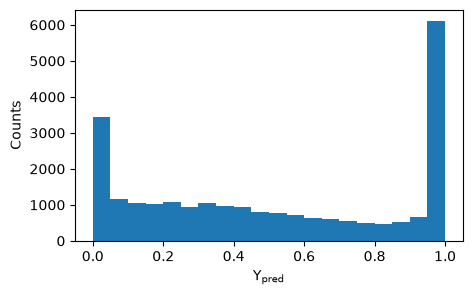

              precision    recall  f1-score   support

           0       0.81      0.85      0.83     11916
           1       0.85      0.81      0.83     12084

    accuracy                           0.83     24000
   macro avg       0.83      0.83      0.83     24000
weighted avg       0.83      0.83      0.83     24000



In [14]:
model.eval()
with torch.no_grad():
    data, data_err, Y_true = train_dataset.tensors
    results = model(data, data_err)
    
    Y_pred = results['classification_prediction'].detach().cpu().numpy()
    Y_pred_labels = (np.array(Y_pred) > 0.5).astype(int) #Use 0.5 as a threshold


plt.figure(figsize = (5,3))
plt.hist(Y_pred, bins = 20)
plt.xlabel(r'Y$_{\rm pred}$')
plt.ylabel('Counts')
plt.show()

print(classification_report(Y_true, Y_pred_labels))

Let's look at how well the model classifies the test set. This code is the same as above, but with the test dataset instead. The model still works well!

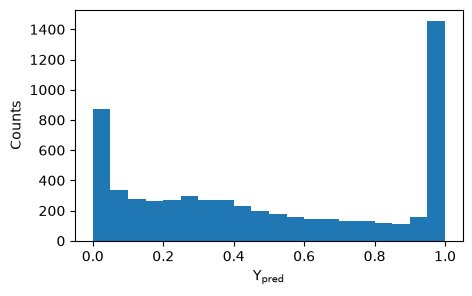

              precision    recall  f1-score   support

           0       0.81      0.87      0.84      3057
           1       0.85      0.79      0.82      2943

    accuracy                           0.83      6000
   macro avg       0.83      0.83      0.83      6000
weighted avg       0.83      0.83      0.83      6000



In [15]:
model.eval()
with torch.no_grad():
    data, data_err, Y_true = test_dataset.tensors
    results = model(data, data_err)
    
    Y_pred = results['classification_prediction'].detach().cpu().numpy()
    Y_pred_labels = (np.array(Y_pred) > 0.5).astype(int)


plt.figure(figsize = (5,3))
plt.hist(Y_pred, bins = 20)
plt.xlabel(r'Y$_{\rm pred}$')
plt.ylabel('Counts')
plt.show()

print(classification_report(Y_true, Y_pred_labels))

The flexAE model is now trained and tested on simulated data to identify unresolved binaries in Rubin LSST photometry. We will now apply this model to real data from Rubin to find actual binary systems. This will be implemented in the future; see Géron et al. (2026). 